# Project 3 :- Sales / Demand Forecasting 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ecommerce_sales_data.csv")

In [3]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [4]:
df.shape

(3500, 7)

In [5]:
df.columns

Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

In [9]:
df.describe()

,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


In [10]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day
df["Weekday"] = df["Order Date"].dt.weekday

In [11]:
df.drop(["Order Date","Product Name"], axis=1, inplace=True)
# Date --> not necessary here
# Product Name has too many unique values → overfitting risk

In [12]:
df.head()

,Category,Region,Quantity,Sales,Profit,Year,Month,Day,Weekday
0,Office,North,4,3640,348.93,2024,12,31,1
1,Accessories,East,7,1197,106.53,2022,11,27,6
2,Electronics,South,5,5865,502.73,2022,5,11,2
3,Accessories,South,2,786,202.87,2024,3,16,5
4,Accessories,West,1,509,103.28,2022,9,10,5


In [13]:
df["Region"].value_counts()

Region
West     898
South    883
East     861
North    858
Name: count, dtype: int64

In [14]:
df["Category"].value_counts()

Category
Electronics    1742
Accessories    1401
Office          357
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

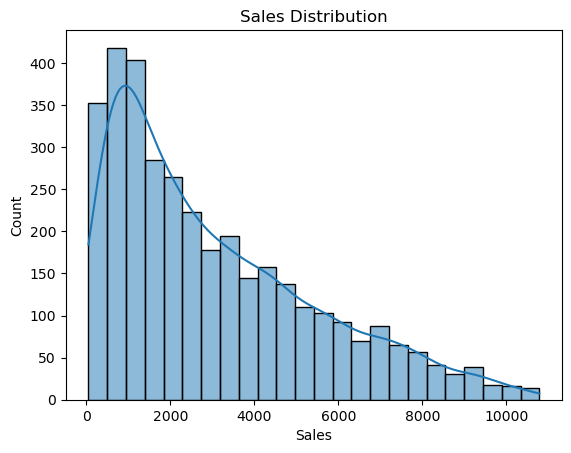

In [15]:
sns.histplot(df["Sales"], kde=True)
plt.title("Sales Distribution")
plt.show()

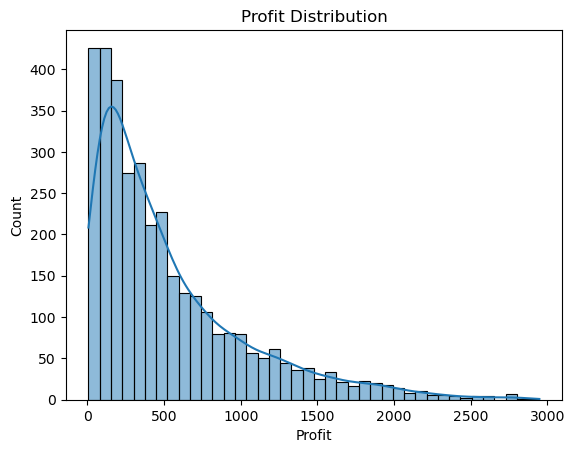

In [16]:
sns.histplot(df["Profit"], kde=True)
plt.title("Profit Distribution")
plt.show()

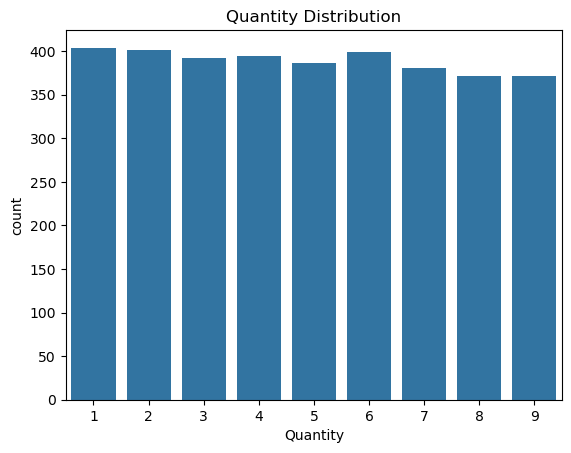

In [17]:
sns.countplot(x=df["Quantity"])
plt.title("Quantity Distribution")
plt.show()

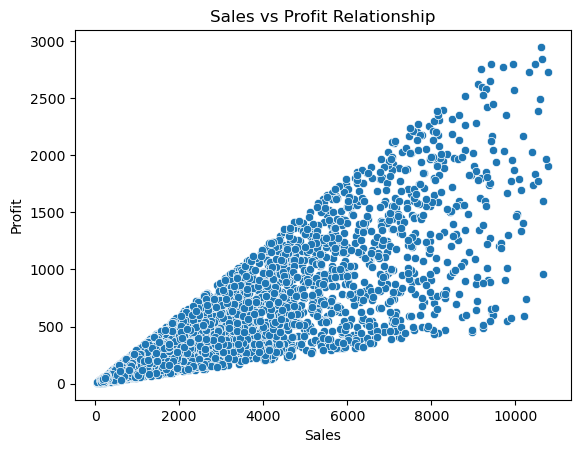

In [18]:
sns.scatterplot(x=df["Sales"], y=df["Profit"])
plt.title("Sales vs Profit Relationship")
plt.show()

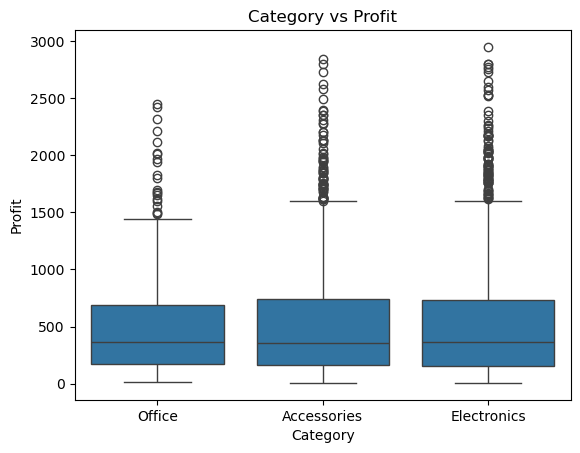

In [19]:
sns.boxplot(x=df["Category"], y=df["Profit"])
plt.title("Category vs Profit")
plt.show()

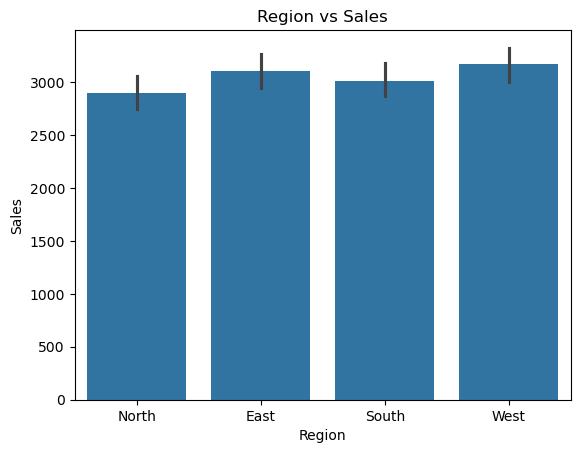

In [20]:
sns.barplot(x=df["Region"], y=df["Sales"])
plt.title("Region vs Sales")
plt.show()

# One Hot Encoding 

In [21]:
# “Label encoding is not suitable here because it introduces false ranking among categories.”
# so,, m one hot encoding use kar rhi hu

df = pd.get_dummies(df,drop_first=True)

# Correlation Heatmap

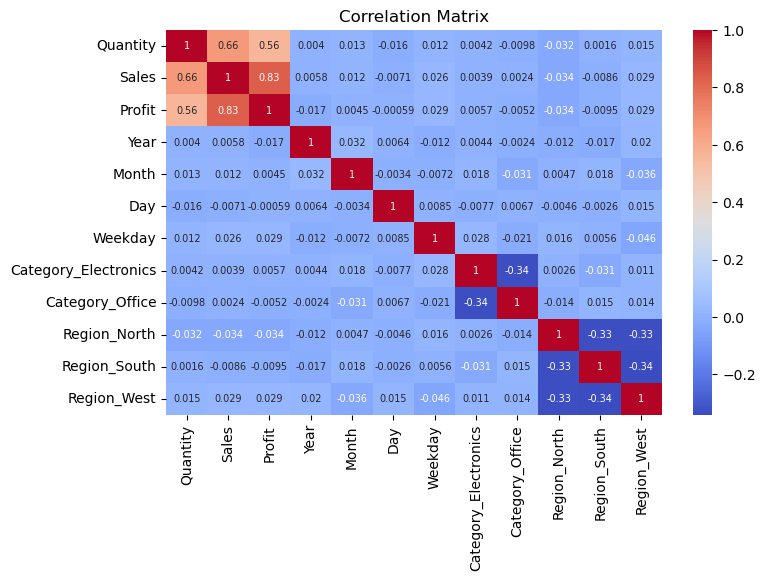

In [22]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm",annot_kws = {"size":7})
plt.title("Correlation Matrix")
plt.show()

In [23]:
X = df.drop("Profit", axis=1)
y = df["Profit"]

# train-test-split

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# LinearRegression

In [25]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# Random Forest Regressor 

In [26]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300,max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Decision Tree Regressor

In [27]:
from sklearn.tree import DecisionTreeRegressor


dt = DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

# Evaluation

In [28]:
from sklearn.metrics import r2_score

acc_lr = r2_score(y_test, y_pred_lr) * 100
acc_dt = r2_score(y_test, y_pred_dt) * 100
acc_rf = r2_score(y_test, y_pred_rf) * 100

print("Linear Regression Accuracy:", acc_lr, "%")
print("Decision Tree Accuracy:", acc_dt, "%")
print("Random Forest Accuracy:", acc_rf, "%")

Linear Regression Accuracy: 65.22367677379918 %
Decision Tree Accuracy: 59.558673044426094 %
Random Forest Accuracy: 62.309126488481645 %
